# Ext. Fig. 7: Anatomical mapping analysis

Requires z-stack data. If you're really keen to run this on the original data,  \
please request the z-stack files from the authors (we didn't post them because  \
they are raw scans and are very large files).

In [1]:
# imports
import os
import pickle
import dill

import numpy as np
import scipy as sp
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import gridspec

from reward_relative import zstack_metadata 
from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import dayData as dd

import TwoPUtils as tpu
import reward_relative as da
from reward_relative import preprocessing
from reward_relative import zalign

import suite2p as s2p
import seaborn as sns

%matplotlib inline

%load_ext autoreload
%autoreload 2


In [2]:
from reward_relative.path_dict_firebird import path_dictionary as path_dict
fig_dir = ut.make_fig_dir(path_dict)
pt.set_fig_params(fontsize=12)

/data/2P/fig_scratch/Jun2025


### Load multiDayData

In [3]:
experiment = 'MetaLearn'
exp_days = [3, 5, 7, 8, 10, 12, 14]

max_anim_list = dd.max_anim_list(experiment,exp_days, year='combined')
ts_key = 'dff' # used to find place field peaks

    
dt = "202504"

pkl_name = "m%s-%s_expdays%s_multiDayData_%s_%s.pickle" % (ut.get_mouse_number(max_anim_list[0]),
                                                           ut.get_mouse_number(
                                                               max_anim_list[-1]),
                                                           ut.make_day_tag(
                                                               exp_days),
                                                           ts_key,
                                                           dt)

pkl_path = os.path.join(path_dict['preprocessed_root'],'multiDayData',pkl_name)
print(pkl_path)
multiDayData = dill.load(open(pkl_path,"rb"))

include_ans = multiDayData[exp_days[-1]].circ_rel_stats_across_an['include_ans']
max_anim_list = sorted(np.unique(np.concatenate([multiDayData[day].anim_list
                                                     for day in exp_days])), 
                           key=len)

/data/2P/multiDayData/m2-19_expdays3-5-7-8-10-12-14_multiDayData_dff_202504.pickle


In [4]:
include_ans = multiDayData[exp_days[0]].circ_rel_stats_across_an['include_ans']
include_ans

array(['GCAMP3', 'GCAMP4', 'GCAMP7', 'GCAMP11', 'GCAMP12', 'GCAMP13',
       'GCAMP14', 'GCAMP15', 'GCAMP17', 'GCAMP18', 'GCAMP19'], dtype='<U7')

In [10]:
## Get CA1 pyramidal layer curvature estimates per animal from the zstacks
z_surface = {} # to save surface estimates per animal
z_depth_per_cell = {}
save_surf_pickle = False

for mouse in include_ans:

    ## Get path to zstack and header info
    zstack_path = zstack_metadata.get_filename(mouse)
    info = zstack_metadata.get_mat(mouse)
    print(mouse, ' ', zstack_path)
    
    ## Get start frames of each step
    step_starts, schedule = zalign.get_step_starts(info)
    ## Register each frame to the mean of each step, and create registered z-stack
    stack = zalign.register_zstack(zstack_path, info, step_starts)

    # mean-normalized data within plane
    data_norm = stack/stack.mean(axis=-2,keepdims=True).mean(axis=-1,keepdims=True) 

    ## Estimate surface from the darkest points in each vertical slice through z
    ##   (looking for the nuclei of the pyramidal layer)
    ## Returns a smoothed surface where values correspond to steps in the z-stack,
    ## where values closer to 0 are more dorsal, closer to 50 is more ventral
    ## NOTE: values near the edges will be unreliable because the z-stack is usually too
    ##    dark there to discern nuclei, or the plane of imaging naturally falls off.
    ##    But these edges are usually excluded from ROI detection anyway given the motion
    ##    correction. Just be aware there may be noisy estimates for any ROIs near the edges

    surf_sm = zalign.estimate_surface(data_norm) # returns imputed and smoothed surface

    z_surface[mouse] = surf_sm
    z_depth_per_cell[mouse] = {}
    

# Save the surface estimates
if save_surf_pickle:
    pkl_name = ("anim%s_z_surface.pickle" % (ut.make_anim_tag(include_ans)))
    save_surf = open(os.path.join(path_dict['preprocessed_root'],pkl_name), "wb")
    dill.dump(z_surface, save_surf)
    save_surf.close()
    

GCAMP3   /mnt/oak/InVivoDA/2P_Data/GCAMP3/14_10_2022/Zstack/Zstack_001_003
motion correcting z-stack...
estimating CA1 surface...
GCAMP4   /mnt/oak/InVivoDA/2P_Data/GCAMP4/20_10_2022/Zstack/Zstack_001_006
motion correcting z-stack...
estimating CA1 surface...
GCAMP7   /mnt/oak/InVivoDA/2P_Data/GCAMP7/30_10_2022/Zstack/Zstack_001_004
motion correcting z-stack...
estimating CA1 surface...
GCAMP11   /mnt/oak/InVivoDA/2P_Data/GCAMP11/08_03_2023/Zstack/Zstack_000_000
motion correcting z-stack...
estimating CA1 surface...
GCAMP12   /mnt/oak/InVivoDA/2P_Data/GCAMP12/07_03_2023/Zstack/Zstack_001_006
motion correcting z-stack...
estimating CA1 surface...
GCAMP13   /mnt/oak/InVivoDA/2P_Data/GCAMP13/08_03_2023/Zstack/Zstack_000_000
motion correcting z-stack...
estimating CA1 surface...
GCAMP14   /mnt/oak/InVivoDA/2P_Data/GCAMP14/07_03_2023/Zstack/Zstack_004_001
motion correcting z-stack...
estimating CA1 surface...
GCAMP15   /mnt/gdrive/2P_Data/GCAMP15/08_04_2024/Zstack/Zstack_001_004
motion corr

In [14]:
roi_im.shape

(512, 796)

/data/2P/sess/GCAMP3/03_10_2022/Env1_LocationC_to_A_001_003.pickle
/data/2P/sess/GCAMP3/05_10_2022/Env1_LocationA_to_B_001_004.pickle
/data/2P/sess/GCAMP3/07_10_2022/Env1_LocationB_to_C_001_001.pickle
/data/2P/sess/GCAMP3/08_10_2022/Env1_C_to_Env2_B_001_002.pickle
/data/2P/sess/GCAMP3/10_10_2022/Env2_LocationB_to_A_001_001.pickle
/data/2P/sess/GCAMP3/12_10_2022/Env2_LocationA_to_C_001_002.pickle
/data/2P/sess/GCAMP3/14_10_2022/Env2_LocationC_to_B_001_002.pickle
/data/2P/sess/GCAMP4/08_10_2022/Env1_LocationB_to_A_001_002.pickle
/data/2P/sess/GCAMP4/10_10_2022/Env1_LocationA_to_C_001_002.pickle
/data/2P/sess/GCAMP4/12_10_2022/Env1_LocationC_to_B_001_002.pickle
/data/2P/sess/GCAMP4/13_10_2022/Env1_B_to_Env2_C_001_002.pickle
/data/2P/sess/GCAMP4/15_10_2022/Env2_LocationC_to_A_001_002.pickle
/data/2P/sess/GCAMP4/17_10_2022/Env2_LocationA_to_B_001_003.pickle
/data/2P/sess/GCAMP4/19_10_2022/Env2_LocationB_to_C_001_002.pickle
/data/2P/sess/GCAMP7/18_10_2022/Env1_LocationA_to_C_001_003.pickle
/

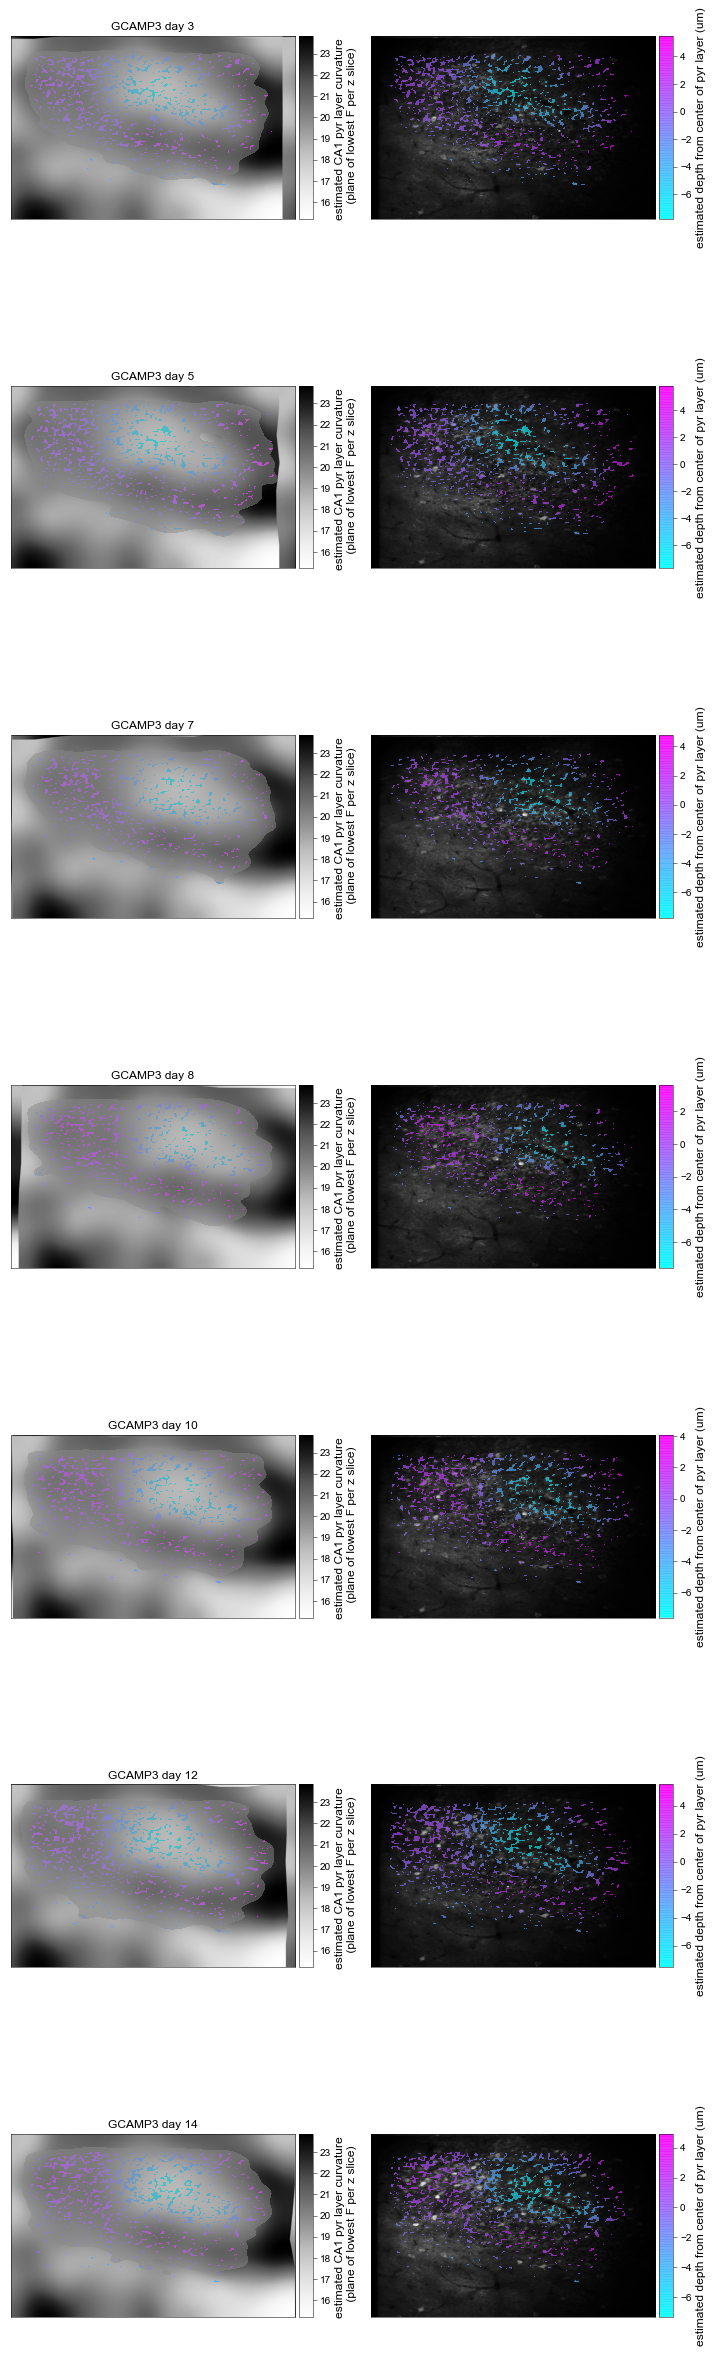

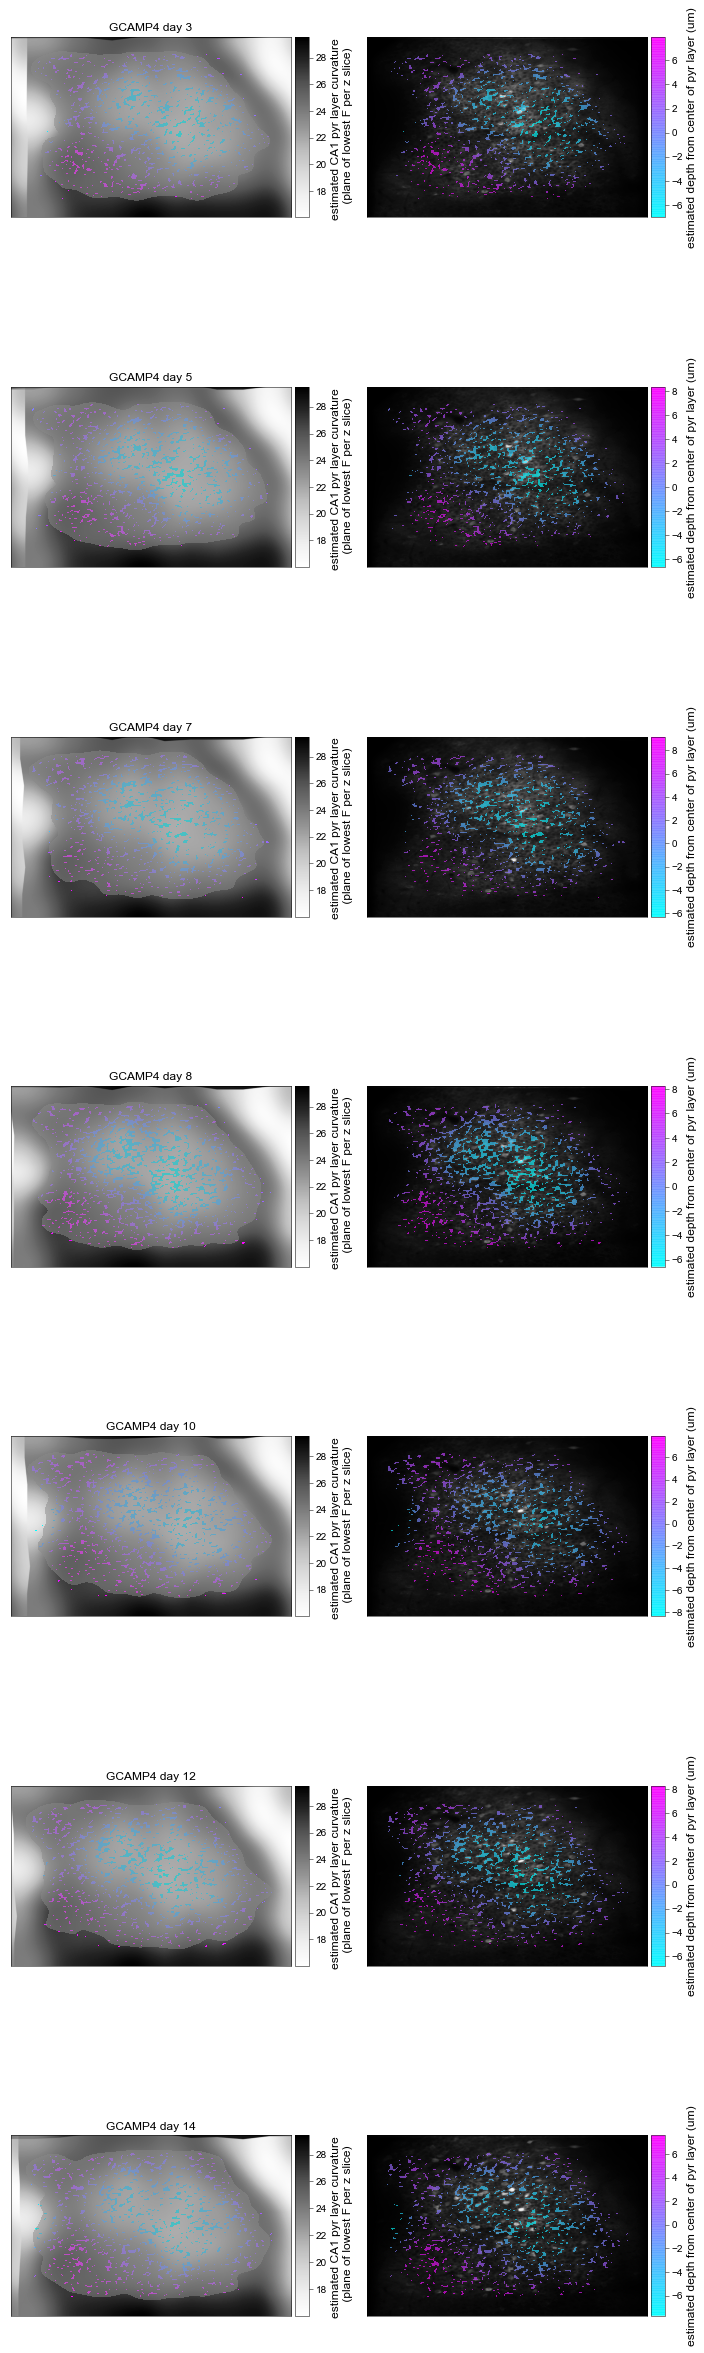

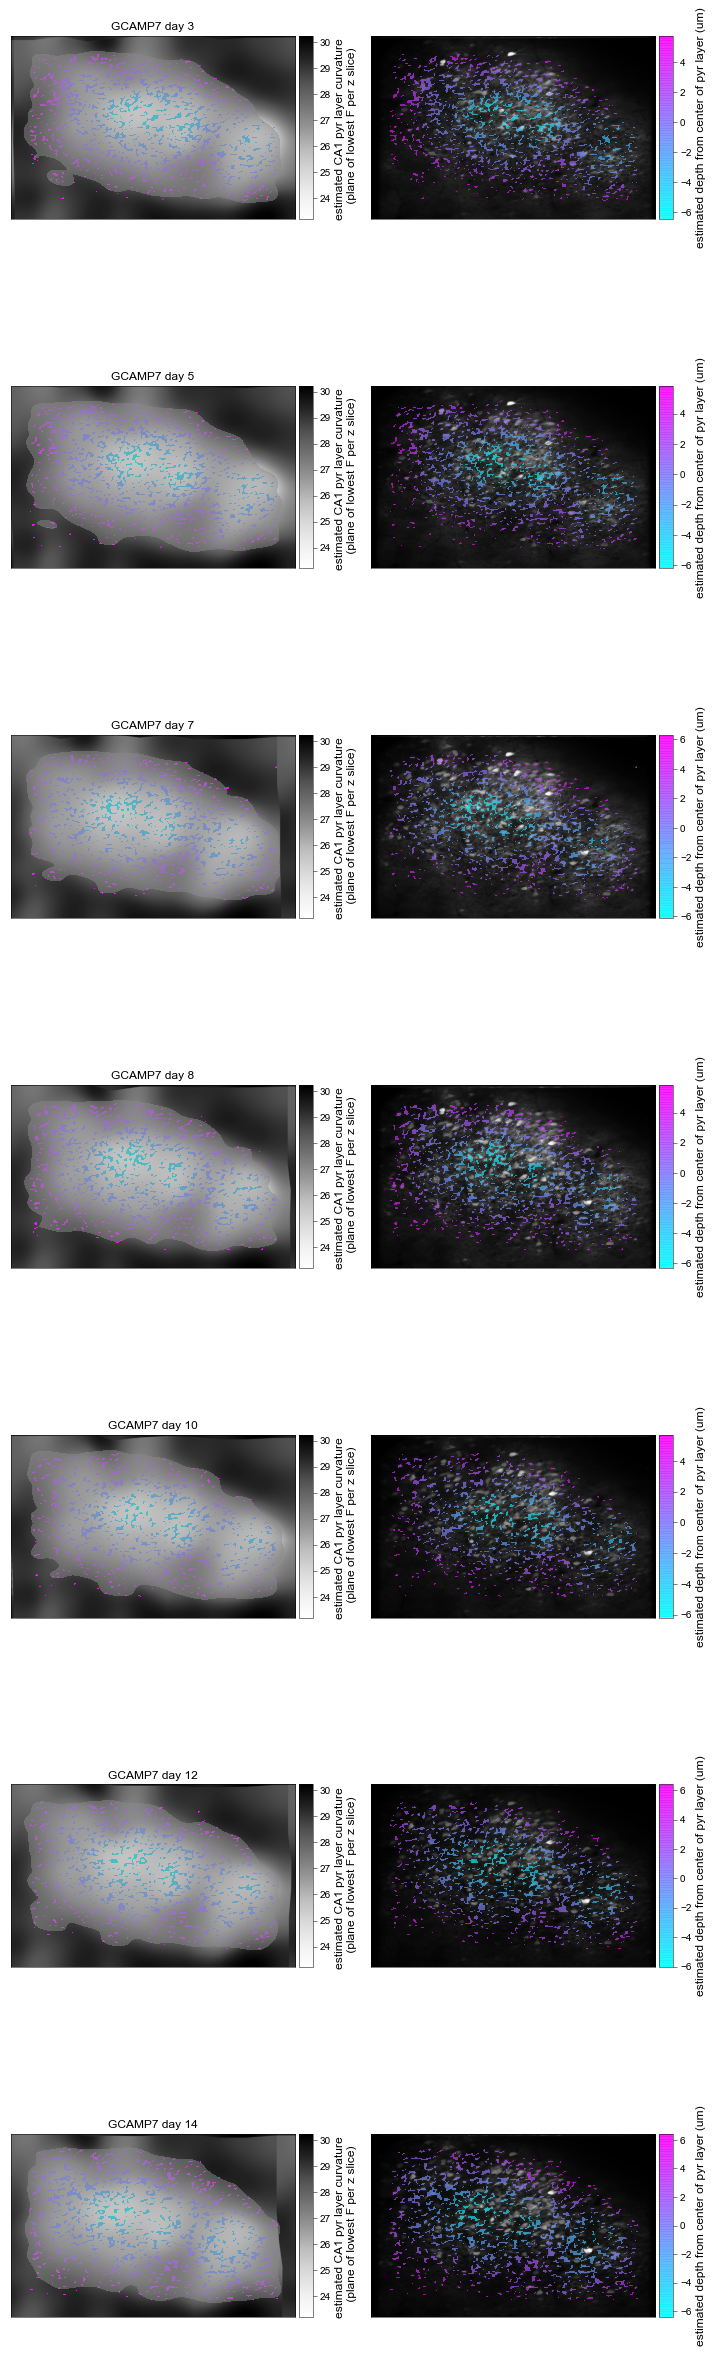

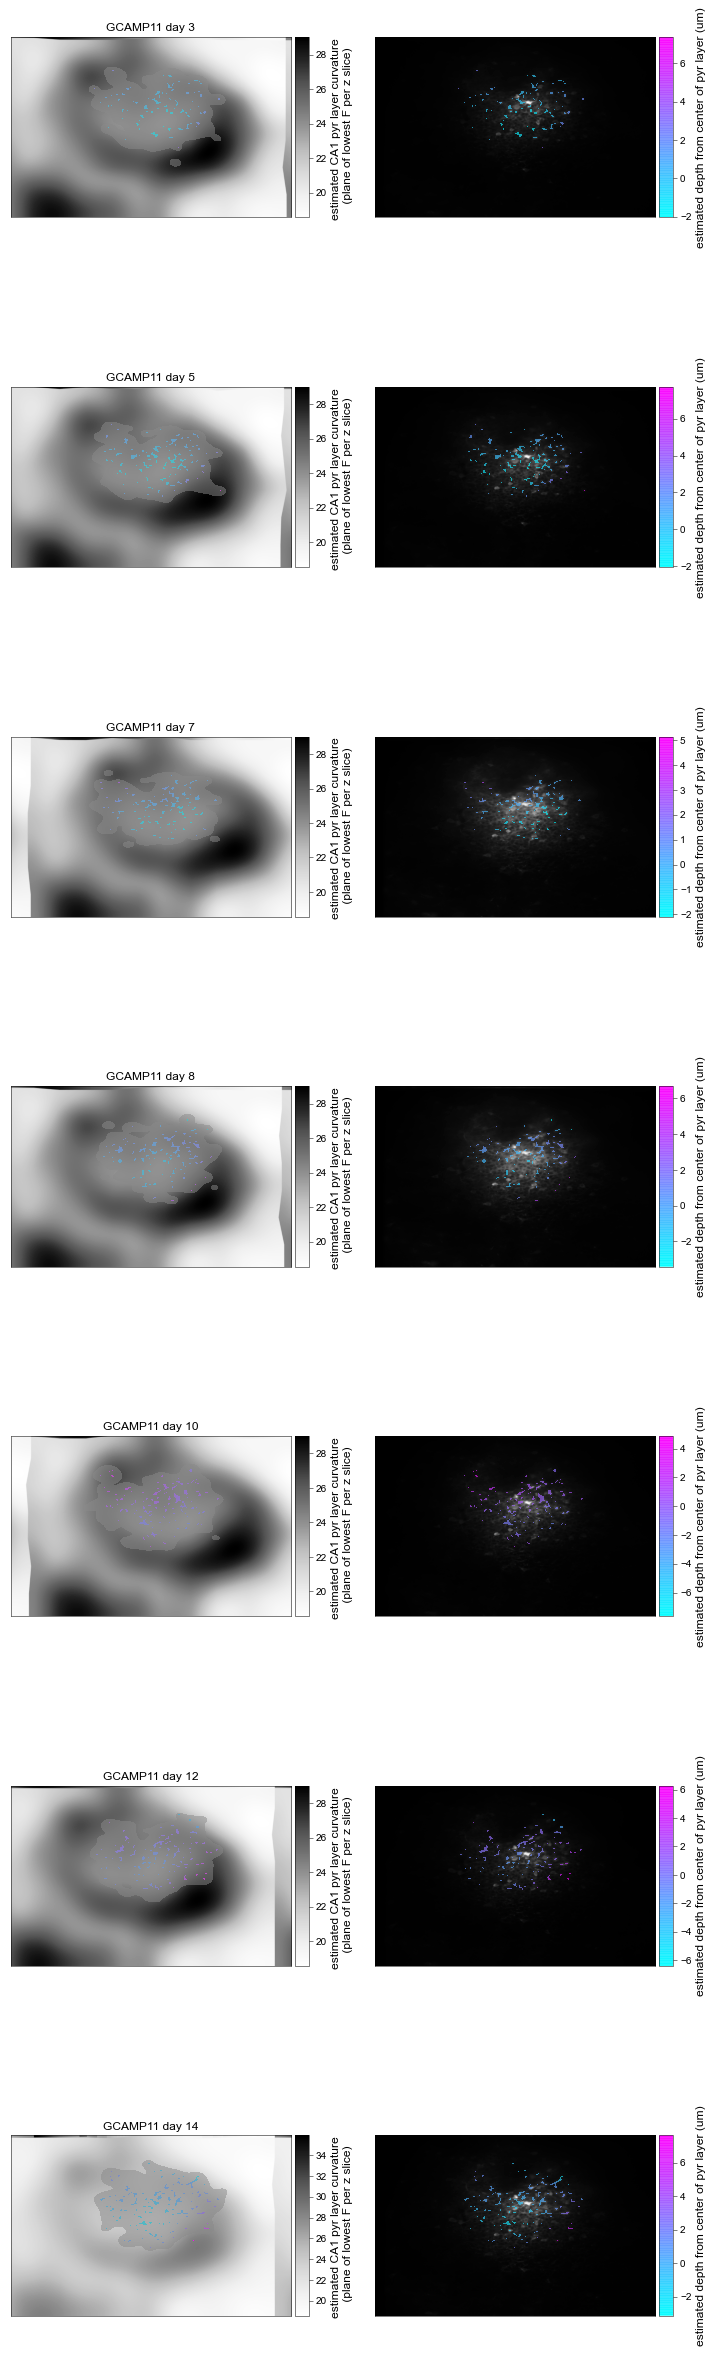

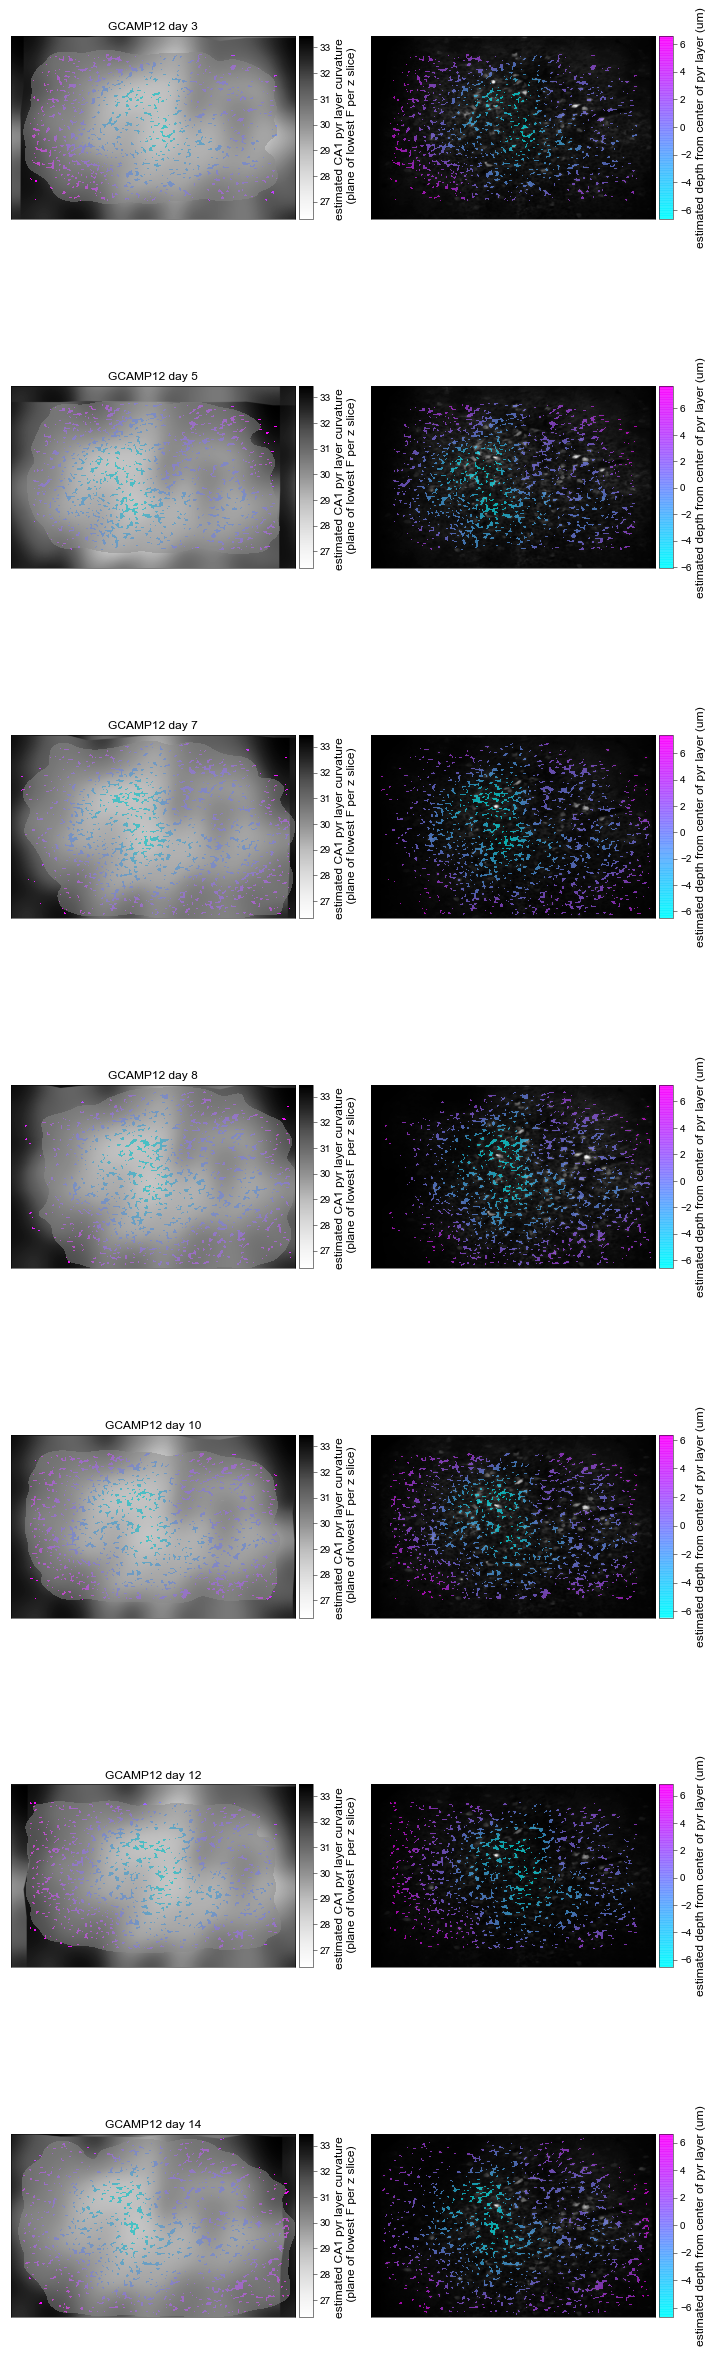

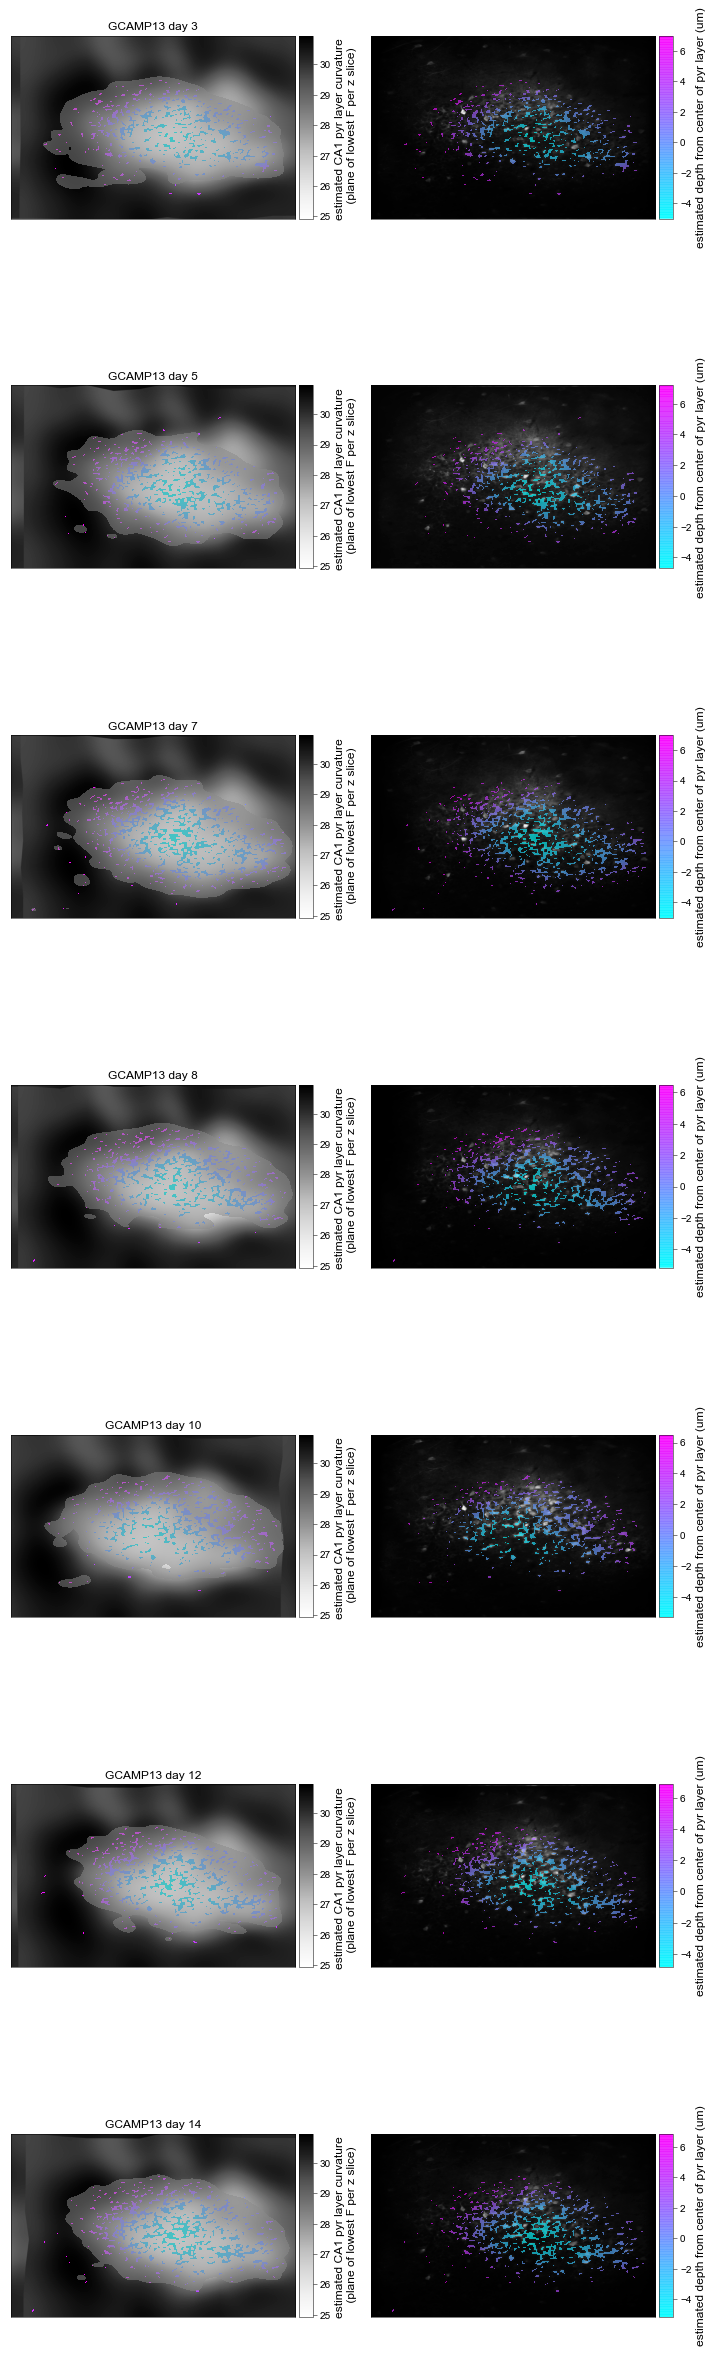

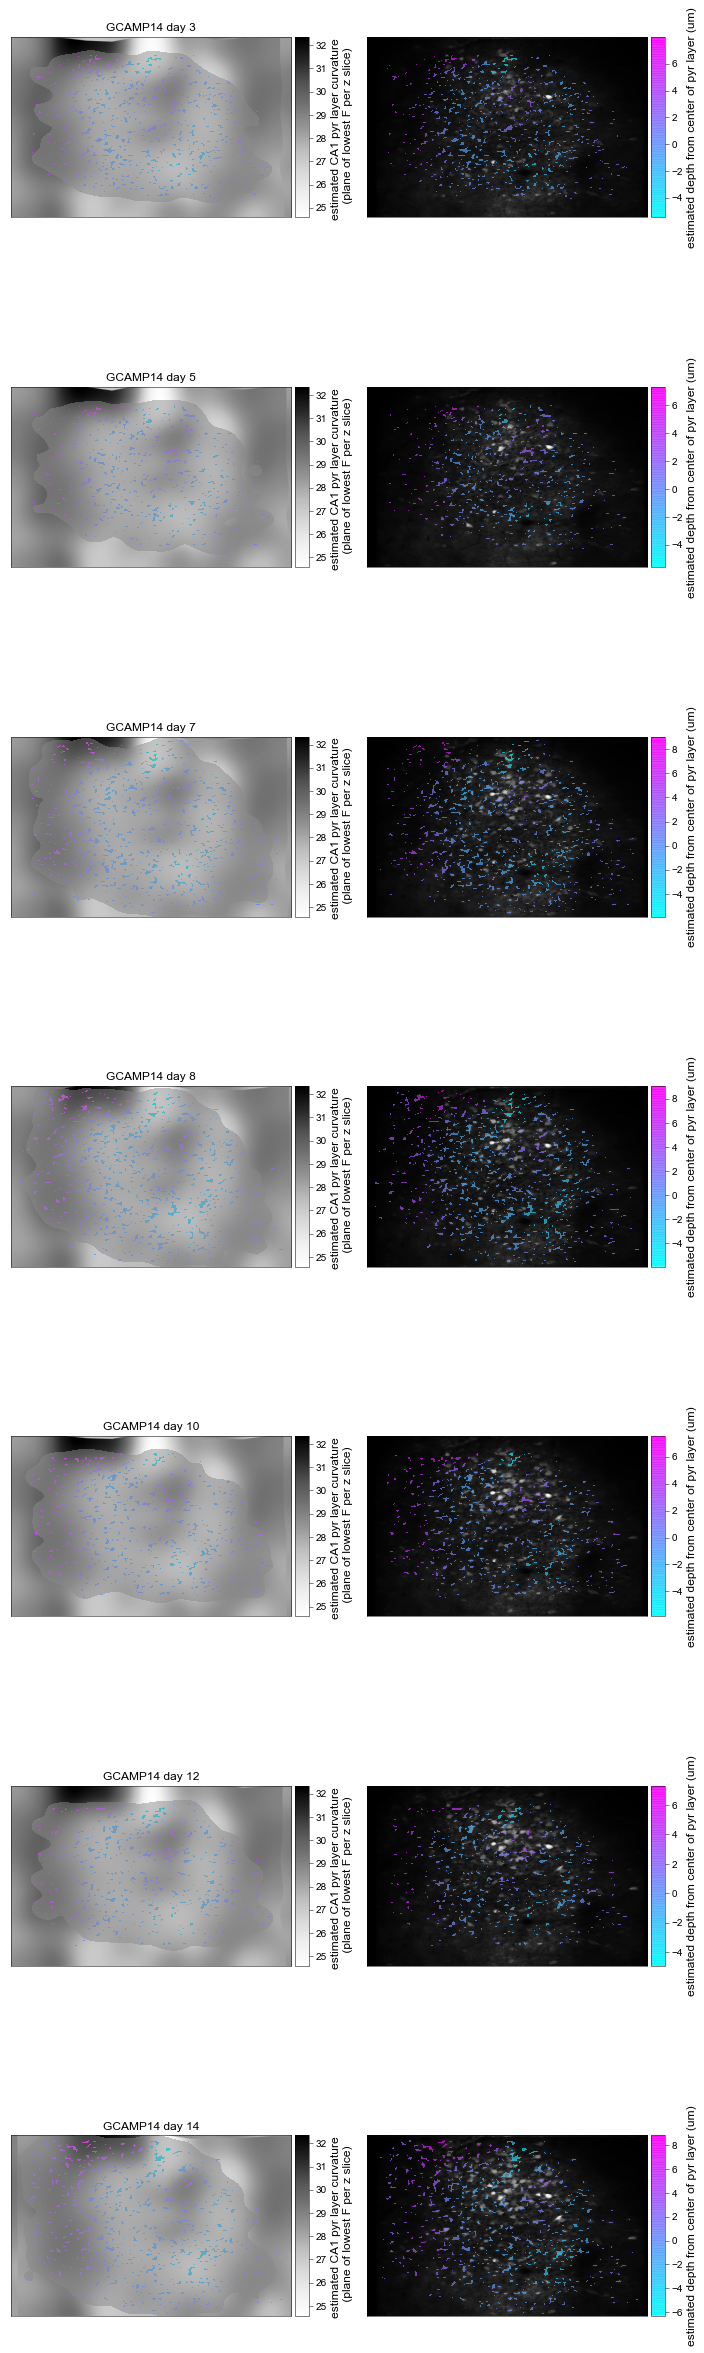

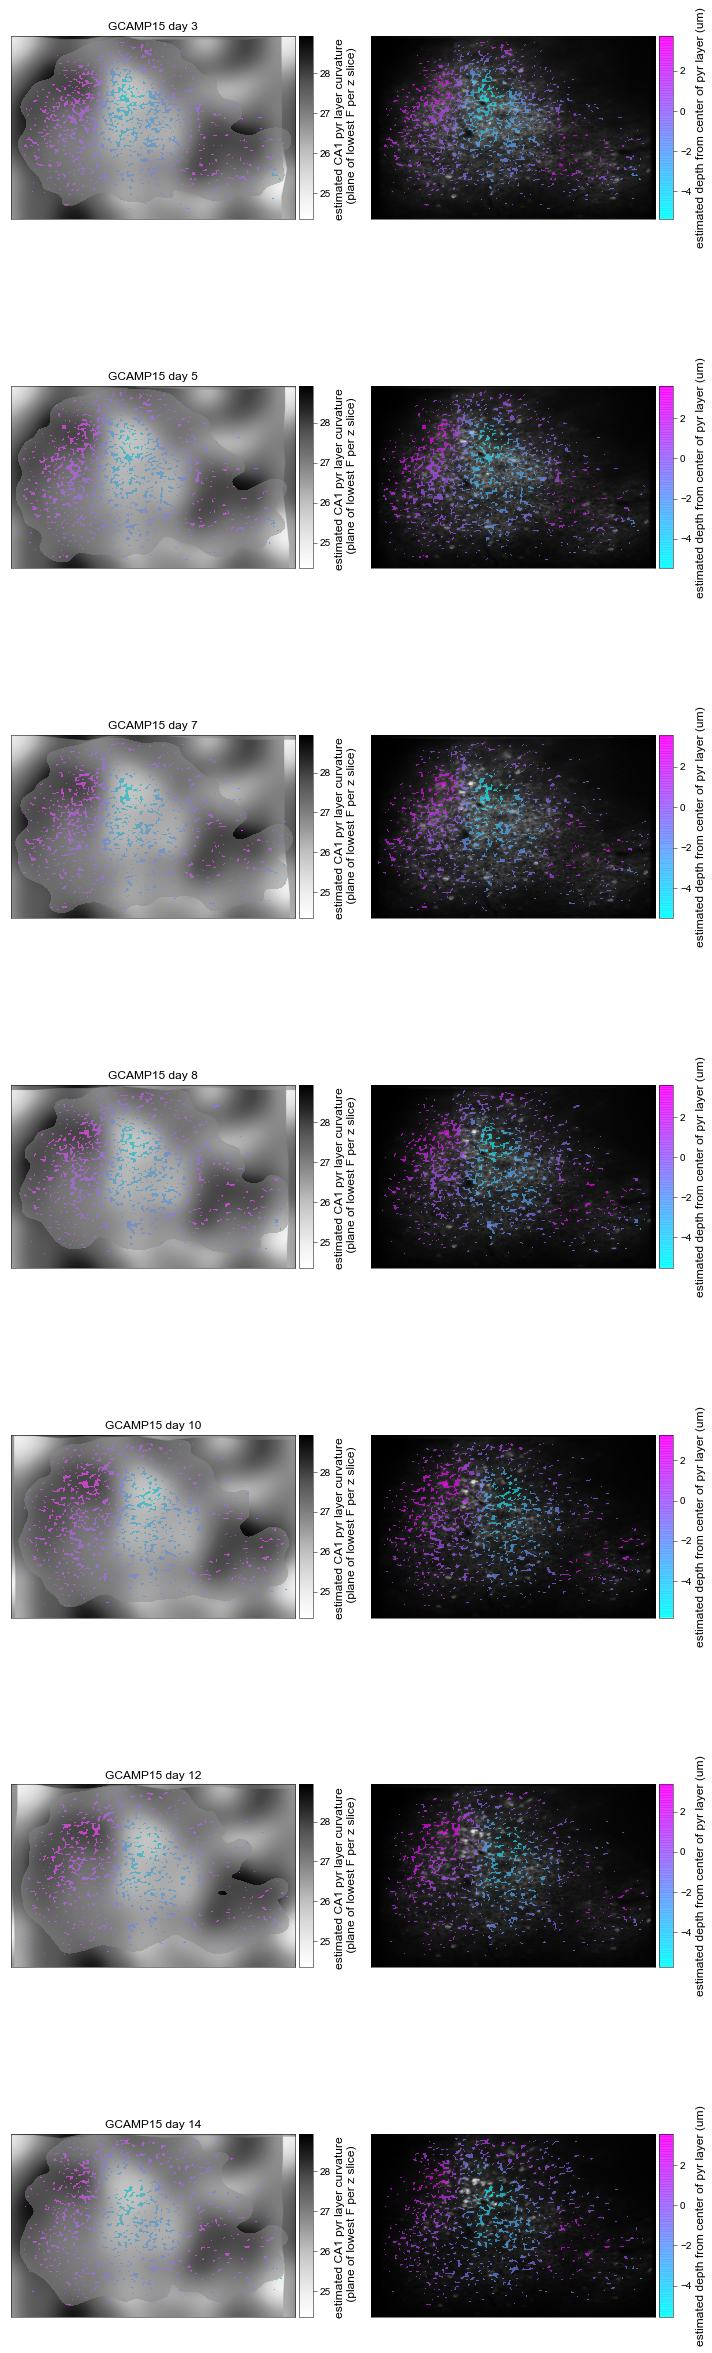

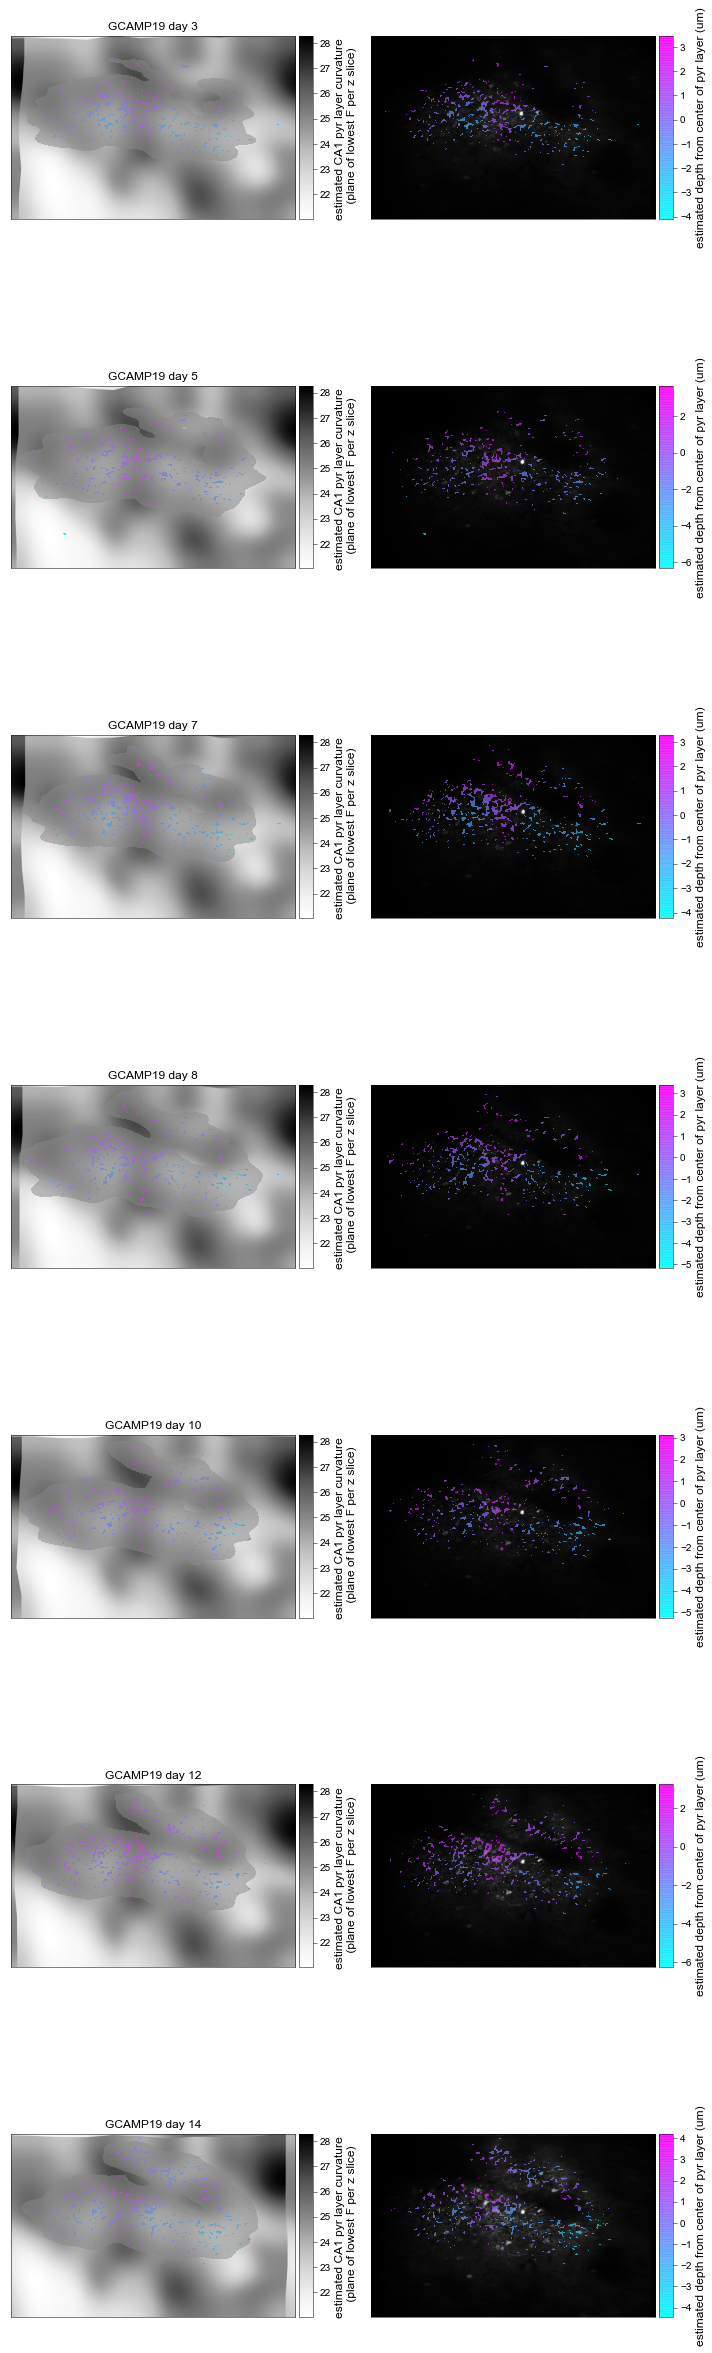

In [15]:
## Now iterate through all mice and days to get depth estimates of each ROI from the surface
save_figures = False

#remove the multiplane animals for this part
use_anim_list = np.copy(include_ans).tolist()
use_anim_list.remove('GCAMP17')
use_anim_list.remove('GCAMP18')

for mouse in use_anim_list:    
    fig, ax = plt.subplots(len(exp_days),2,figsize=[10,5*len(exp_days)])
    
    for d_i, day in enumerate(exp_days):
        
        sess = ut.load_sess_pickle(path_dict['preprocessed_root'],mouse,exp_day=day)
        refImg = sess.s2p_ops['meanImg']
        ops = sess.s2p_ops
        
        # register surface by the same motion correction offsets as day's scan's refImg,
        # to approximately align ROIs to the surface (assuming we did a decent job aligning across days)
        surf_reg = zalign.register_surface_to_ref(z_surface[mouse], refImg, ops)
        
        _stats = sess.s2p_stats # roi pixels for each cell

        step_size = 2 ## currently hardcoded 2 microns! #schedule[:,2]
        
        depth = np.zeros(_stats.shape[0])
        for i, roi in enumerate(_stats):
            # depth comes from the mean surface values of the roi pixels
            depth[i]=np.nanmean(surf_reg[0,roi['ypix'],roi['xpix']])

        # median center the depth, then multiply by the step size to get microns
        depth = (depth-np.nanmedian(depth)) * np.median(step_size)

        roi_im = np.zeros([sess.s2p_ops['Ly'],sess.s2p_ops['Lx']])*np.nan

        for i, roi in enumerate(_stats):

            roi_im[roi['ypix'],roi['xpix']]=depth[i]

        j=ax[d_i,0].imshow(np.squeeze(surf_reg),cmap='Greys')
        kde = sns.kdeplot(x=np.where(
        ~np.isnan(roi_im))[1],
                y=np.where(
                    ~np.isnan(roi_im))[0],
                fill=True, ax=ax[d_i,0], levels=2, alpha=0.5, color='grey')

        ax[d_i,0].imshow(roi_im,cmap='cool') #,vmin=np.percentile(_dff2_red[:,0],5),
                     #vmax=np.percentile(_dff2_red[:,0],95),aspect = 796./512., alpha=1)
        ax[d_i,0].set_xticks([])
        ax[d_i,0].set_yticks([])
        pt.colorbar(j,label='estimated CA1 pyr layer curvature \n (plane of lowest F per z slice)')

        ax[d_i,1].imshow(refImg,cmap="Greys_r") #if you want to make it square: ,aspect=796./512
        # This gives the curvature of pyramidal layer
        # but the depth of each ROI would actually be the inverse of that
        # i.e. if the pyramidal layer has the most dorsal part of its curve in the center of the FOV,
        # then a horizontal slice through that curve means the ROIs at the center of the FOV 
        # will be more ventral (superficial CA1)
        h=ax[d_i,1].imshow(roi_im,cmap='cool', alpha=.65)
        ax[d_i,1].set_xticks([])
        ax[d_i,1].set_yticks([])
        ax[d_i,0].set_title("%s day %d" % (mouse, day))

        pt.colorbar(h, label='estimated depth from center of pyr layer (um)')# deep to superficial')

        z_depth_per_cell[mouse][day] = depth
        
    if save_figures:
        fig.savefig(os.path.join(fig_dir,"%s_day%d-%d_depth_plot_kde.pdf" % (mouse,exp_days[0], exp_days[-1])))
                        

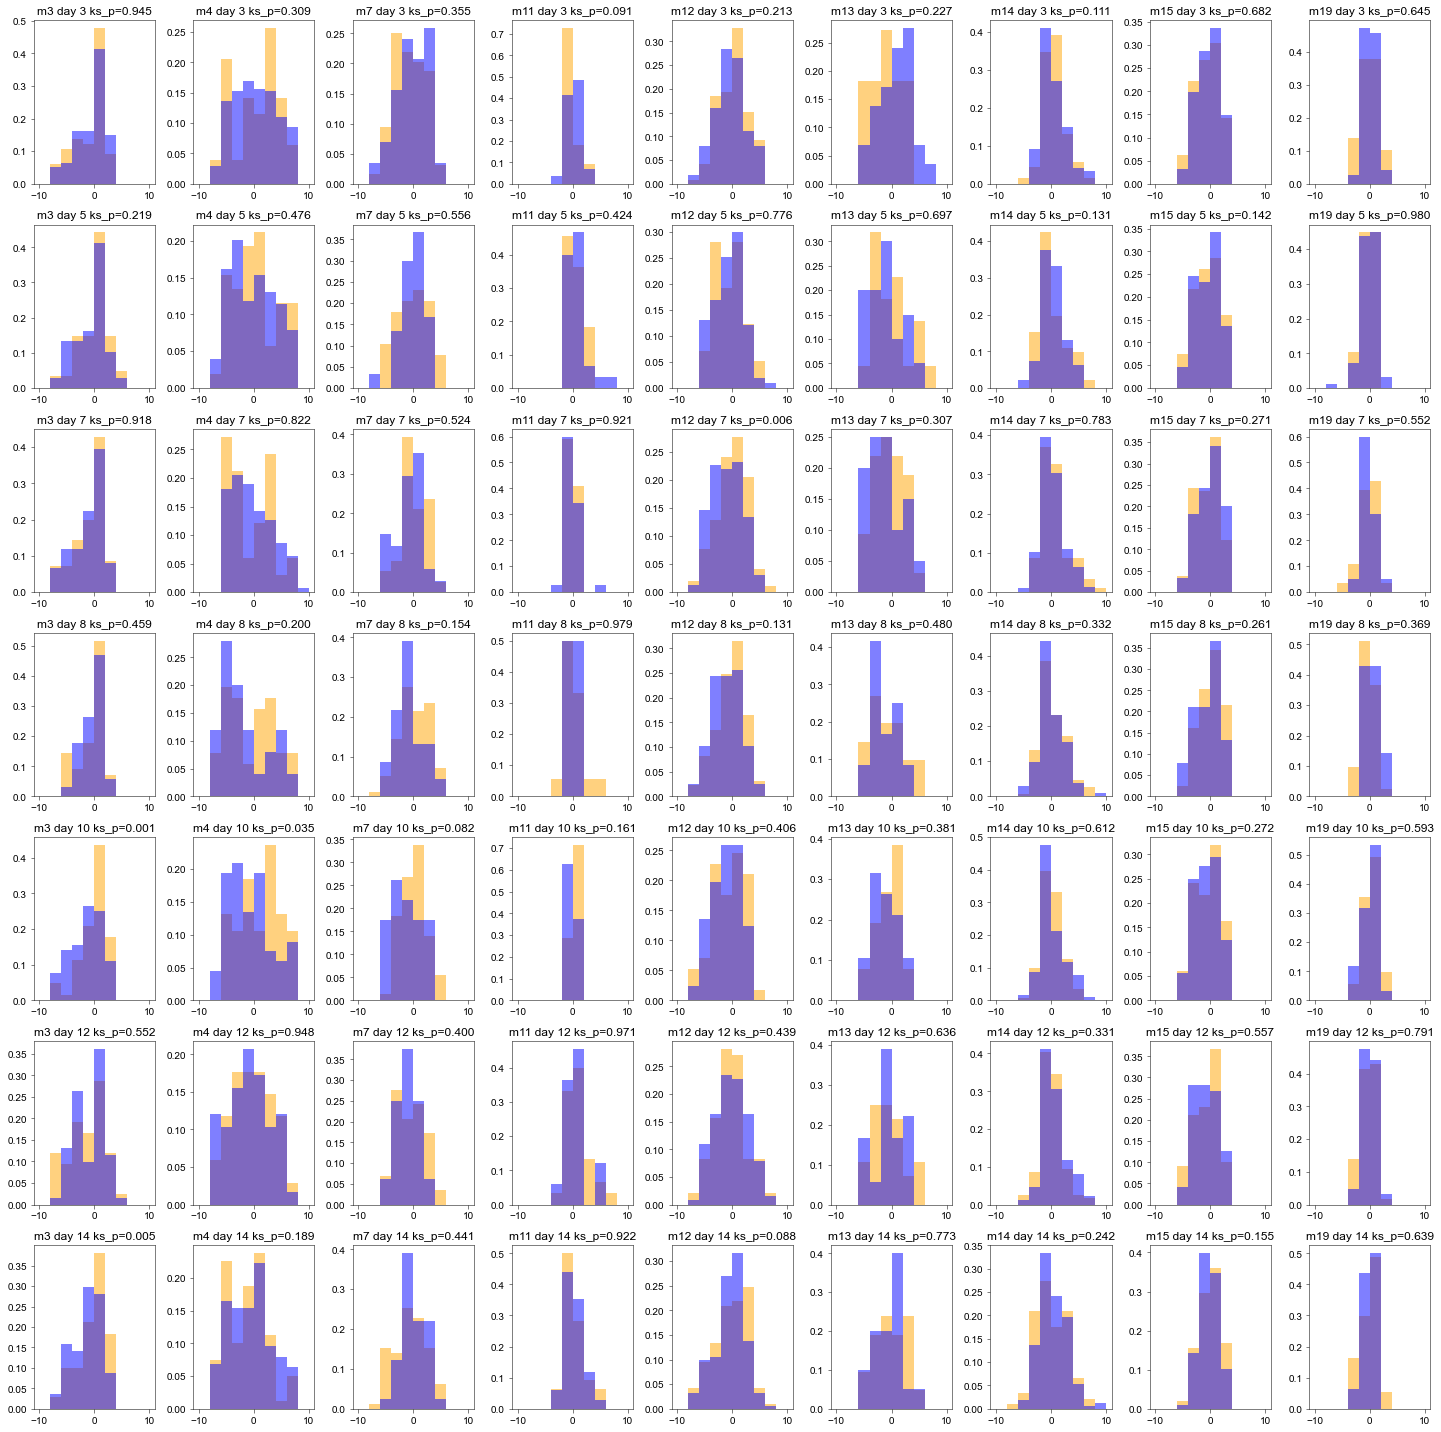

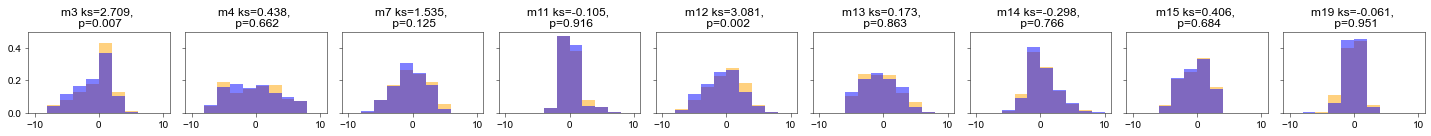

In [16]:
## Plot depths of RR and TR cells as histograms per animal and day
depth_bins = np.arange(-10,12,2)
fig,ax = plt.subplots(len(exp_days), len(use_anim_list), figsize=[20,20])
fig_by_an, ax_by_an = plt.subplots(1, len(use_anim_list), figsize=[20,2], sharey=True)

for an_i, mouse in enumerate(use_anim_list):    
    
    for d_i, day in enumerate(exp_days):
        rr_depths = z_depth_per_cell[mouse][day][multiDayData[day].reward_rel_cell_ids[mouse]]

        tr_inds = np.where(multiDayData[day].cell_class[mouse]['masks']['track'])[0]
        tr_inds = tr_inds[~np.isin(tr_inds, multiDayData[day].reward_rel_cell_ids[mouse])]

        tr_depths = z_depth_per_cell[mouse][day][tr_inds]                                      

        pt.histogram(rr_depths, ax=ax[d_i,an_i], bins=depth_bins, facecolor='orange', alpha=0.5)
        pt.histogram(tr_depths, ax=ax[d_i,an_i], bins=depth_bins, facecolor='blue', alpha=0.5)
        
        ks_stat, ks_p = sp.stats.ks_2samp(rr_depths, tr_depths)
        
        ax[d_i, an_i].set_title("m%s day %d ks_p=%.3f" % (ut.get_mouse_number(mouse), day, ks_p))
        
    rr_depths_alldays = np.concatenate([z_depth_per_cell[mouse][day][multiDayData[day].reward_rel_cell_ids[mouse]]
                                    for day in exp_days])

    tr_depths_alldays = np.concatenate([z_depth_per_cell[mouse][day][
        np.where(multiDayData[day].cell_class[mouse]['masks']['track'])[0][
            ~np.isin(np.where(multiDayData[day].cell_class[mouse]['masks']['track'])[0], 
                     multiDayData[day].reward_rel_cell_ids[mouse])]
    ] for day in exp_days])
    
    pt.histogram(rr_depths_alldays, ax=ax_by_an[an_i], bins=depth_bins, facecolor='orange', alpha=0.5)
    pt.histogram(tr_depths_alldays, ax=ax_by_an[an_i], bins=depth_bins, facecolor='b', alpha=0.5)

    rs_stat_all, rs_p_all = sp.stats.ranksums(rr_depths_alldays, tr_depths_alldays)

    ax_by_an[an_i].set_title("m%s ks=%.3f, \n p=%.3f" % (ut.get_mouse_number(mouse), rs_stat_all, rs_p_all))
    

save_figures = False
if save_figures:
    pt.savefig(fig_by_an, fig_dir, "%s_day%d-%d_depth_distributions_ranksum" % (
        ut.make_anim_tag(use_anim_list),exp_days[0], exp_days[-1]))

## Multiplane anatomical distribution

In [5]:
anim_multiplane = ['GCAMP17','GCAMP18']

frac_rr_cells_per_plane = np.zeros((len(exp_days), 2, len(anim_multiplane)))
frac_tr_cells_per_plane = np.zeros((len(exp_days), 2, len(anim_multiplane)))
frac_all_cells_per_plane = np.zeros((len(exp_days), 2, len(anim_multiplane)))

for an_i, an in enumerate(anim_multiplane):
    for d_i, day in enumerate(exp_days):
        rr_planes = multiDayData[day].plane_per_cell[an][multiDayData[day].reward_rel_cell_ids[an]]
        rr_plane0 = np.sum(rr_planes==0)
        rr_plane1 = np.sum(rr_planes==1)
        frac_rr_cells_per_plane[d_i, 0, an_i] = rr_plane0/len(multiDayData[day].reward_rel_cell_ids[an])
        frac_rr_cells_per_plane[d_i, 1, an_i] = rr_plane1/len(multiDayData[day].reward_rel_cell_ids[an])
        # print(np.sum(frac_rr_cells_per_plane[d_i, :, an_i]))
        
        tr_inds = np.where(multiDayData[day].cell_class[an]['masks']['track'])[0]
        tr_inds = tr_inds[~np.isin(tr_inds, multiDayData[day].reward_rel_cell_ids[an])]
        
        tr_planes = multiDayData[day].plane_per_cell[an][tr_inds]
        tr_plane0 = np.sum(tr_planes==0)
        tr_plane1 = np.sum(tr_planes==1)
        frac_tr_cells_per_plane[d_i, 0, an_i] = tr_plane0/len(tr_inds)
        frac_tr_cells_per_plane[d_i, 1, an_i] = tr_plane1/len(tr_inds)
        
        all_plane0 = np.sum(multiDayData[day].plane_per_cell[an]==0)
        all_plane1 = np.sum(multiDayData[day].plane_per_cell[an]==1)
        frac_all_cells_per_plane[d_i, 0, an_i] = all_plane0/multiDayData[day].plane_per_cell[an].shape[0]
        frac_all_cells_per_plane[d_i, 1, an_i] = all_plane1/multiDayData[day].plane_per_cell[an].shape[0]
        # print(np.sum(frac_tr_cells_per_plane[d_i, :, an_i]))

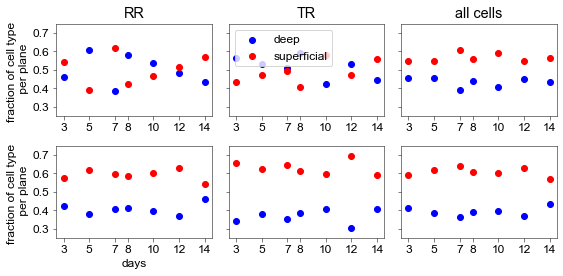

In [6]:
# Top = m17, bottom = m18
fig, ax = plt.subplots(2,3,figsize=(8,4), sharey=True)

for an_i, an in enumerate(anim_multiplane):

    ax[an_i,0].scatter(exp_days, frac_rr_cells_per_plane[:,0,an_i], color='blue', label='deep')
    ax[an_i,0].scatter(exp_days, frac_rr_cells_per_plane[:,1,an_i], color='red', label='superficial')
    
    ax[an_i,1].scatter(exp_days, frac_tr_cells_per_plane[:,0,an_i], color='blue', label='deep')
    ax[an_i,1].scatter(exp_days, frac_tr_cells_per_plane[:,1,an_i], color='red', label='superficial')
    
    ax[an_i,2].scatter(exp_days, frac_all_cells_per_plane[:,0,an_i], color='blue', label='deep')
    ax[an_i,2].scatter(exp_days, frac_all_cells_per_plane[:,1,an_i], color='red', label='superficial')
    
ax[0,1].legend(loc='upper left')
ax[0,0].set_ylabel('fraction of cell type \n per plane')
ax[1,0].set_ylabel('fraction of cell type \n per plane')
ax[0,0].set_title('RR')
ax[0,1].set_title('TR')
ax[0,2].set_title('all cells')
ax[1,0].set_xlabel('days')

[[ax[i,j].set_xticks(exp_days) for i in range(ax.shape[0])] for j in range(ax.shape[1])]
[ax[i,0].set_ylim([0.25, 0.75]) for i in range(ax.shape[0])]
[ax[i,0].set_yticks(np.arange(0.3,0.8,0.1)) for i in range(ax.shape[0])]
save_figures = False
if save_figures:
    pt.savefig(fig, fig_dir, "multiplaneAn%s_fractionRRTR" % (
        ut.make_anim_tag(anim_multiplane))
    )

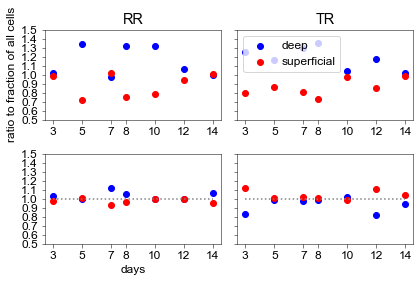

In [7]:
# plot normalized to fraction of all cells per plane
# Top = m17, bottom = m18

fig, ax = plt.subplots(2,2,figsize=(6,4), sharey=True)

for an_i, an in enumerate(anim_multiplane):
    ax[an_i,0].scatter(exp_days, frac_rr_cells_per_plane[:,0,an_i]/frac_all_cells_per_plane[:,0,an_i], 
                       color='blue', label='deep')
    ax[an_i,0].scatter(exp_days, frac_rr_cells_per_plane[:,1,an_i]/frac_all_cells_per_plane[:,1,an_i], 
                       color='red', label='superficial')
    
    ax[an_i,1].scatter(exp_days, frac_tr_cells_per_plane[:,0,an_i]/frac_all_cells_per_plane[:,0,an_i], color='blue', label='deep')
    ax[an_i,1].scatter(exp_days, frac_tr_cells_per_plane[:,1,an_i]/frac_all_cells_per_plane[:,1,an_i], color='red', label='superficial')
    
    
ax[0,1].legend(loc='upper left')
ax[0,0].set_ylabel('ratio to fraction of all cells')
ax[0,0].set_title('RR')
ax[0,1].set_title('TR')
[[ax[i,j].set_xticks(exp_days) for i in range(ax.shape[0])] for j in range(ax.shape[1])]
[ax[i,0].set_ylim([0.5, 1.5]) for i in range(ax.shape[0])]
[ax[i,0].set_yticks(np.arange(0.5,1.6,0.1)) for i in range(ax.shape[0])]
ax[1,0].set_xlabel('days')
ax[1,0].hlines(1, exp_days[0], exp_days[-1], color='grey', linestyle = ":")
ax[1,1].hlines(1, exp_days[0], exp_days[-1], color='grey', linestyle = ":")

save_figures = False
if save_figures:
    pt.savefig(fig, fig_dir, "multiplaneAn%s_fractionRRTR_normalized" % (
        ut.make_anim_tag(anim_multiplane))
    )

In [24]:
include_ans = multiDayData[3].circ_rel_stats_across_an['include_ans']

/data/2P/sess/GCAMP18/07_04_2024/Env1_LocationA_to_C_004_014.pickle


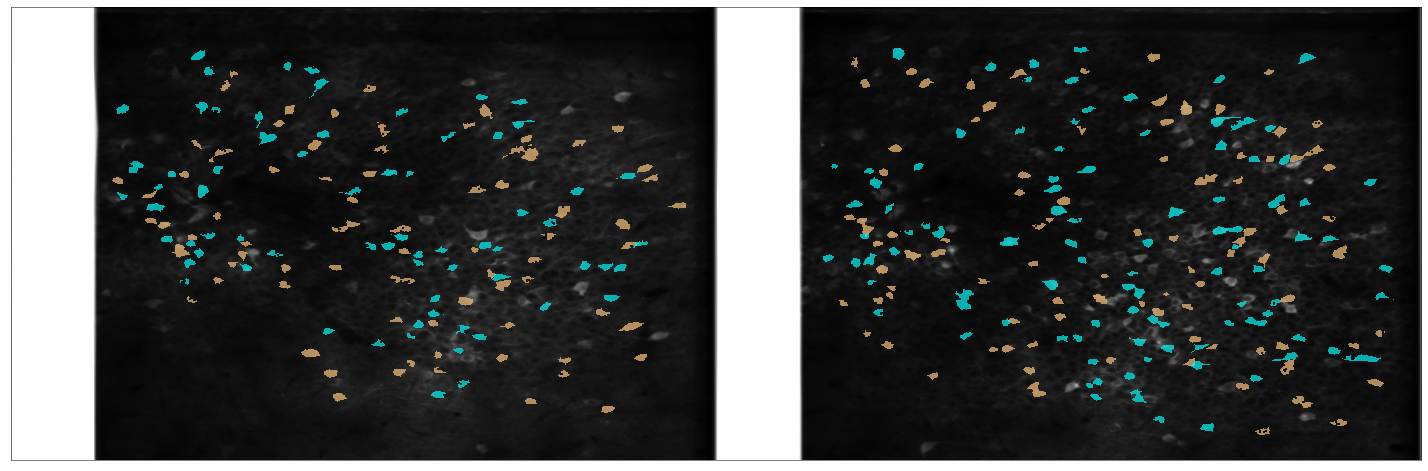

In [5]:
# For multiplane animals: Load sess from this day and plot FOV with ROIs colored by RR/TR
save_figures = False
day = 14
for an in ['GCAMP18']:
    sess = ut.load_sess_pickle(path_dict['preprocessed_root'],an,exp_day=day)
    
    refImg = sess.s2p_ops['meanImg']
    
    _stats = sess.s2p_stats #[sess.iscell[:,0]>0]

    
    fig, ax = plt.subplots(1,1,figsize=[20,10])
    
    # for plane in [0,1]:
    roi_RR = np.zeros([sess.s2p_ops['Ly'],sess.s2p_ops['Lx']])*np.nan
    roi_TR = np.zeros([sess.s2p_ops['Ly'],sess.s2p_ops['Lx']])*np.nan
    roi_RR_COM = np.zeros((len(multiDayData[day].reward_rel_cell_ids[an]),2))
    
    tr_inds = np.where(multiDayData[day].cell_class[an]['masks']['track'])[0]
    tr_inds = tr_inds[~np.isin(tr_inds, multiDayData[day].reward_rel_cell_ids[an])]
    roi_TR_COM = np.zeros((len(tr_inds),2))
    
    rr_planes = multiDayData[day].plane_per_cell[an][multiDayData[day].reward_rel_cell_ids[an]]
    tr_planes = multiDayData[day].plane_per_cell[an][tr_inds]

    for i, roi in enumerate(multiDayData[day].reward_rel_cell_ids[an]): #[rr_planes==plane]

        this_roi_mask = np.zeros([sess.s2p_ops['Ly'],sess.s2p_ops['Lx']])
        this_roi_mask[_stats[roi]['ypix'],_stats[roi]['xpix']]=1
        roi_RR[_stats[roi]['ypix'],_stats[roi]['xpix']]=1
        
        roi_RR_COM[i,:] = sp.ndimage.center_of_mass(this_roi_mask)

    for i, roi in enumerate(tr_inds):

        this_roi_mask = np.zeros([sess.s2p_ops['Ly'],sess.s2p_ops['Lx']])
        this_roi_mask[_stats[roi]['ypix'],_stats[roi]['xpix']]=1
        roi_TR[_stats[roi]['ypix'],_stats[roi]['xpix']]=1
        
        roi_TR_COM[i,:] = sp.ndimage.center_of_mass(this_roi_mask)

    h=ax.imshow(refImg,aspect=refImg.shape[1]/refImg.shape[0],cmap="Greys_r",vmax=np.percentile(refImg,88.5))
    j=ax.imshow(roi_RR,cmap='copper_r', alpha=0.68) 
    # ax.scatter(roi_RR_COM[:,1],roi_RR_COM[:,0], s=10, color='m' )
    ax.imshow(roi_TR,cmap='cool', alpha=0.68)
    ax.set_xticks([])
    ax.set_yticks([])
 
    if save_figures:
        fig.savefig(os.path.join(fig_dir, ("%s_day%d_refImg_RRTR_ROIs.pdf" % (an, day))))
    

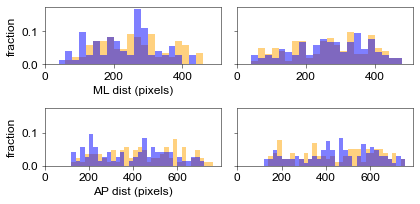

In [6]:
## Get ROI centers of mass as histogram
ML_bins = np.arange(0,512,20)
AP_bins = np.arange(0,796,20)
fig, ax = plt.subplots(2,2,figsize=[6,3], sharey=True)
ML_hist = pt.histogram(roi_RR_COM[rr_planes==0,0], ax=ax[0,0], bins=ML_bins, facecolor='orange', alpha=0.5)

ax[0,0].set_xlabel('ML dist (pixels)')
ax[0,0].set_ylabel('fraction')
ax[0,0].set_xlim([0,512]), ax[0,1].set_xlim([0,512])
AP_hist = pt.histogram(roi_RR_COM[rr_planes==0,1], ax=ax[1,0], bins=AP_bins, facecolor='orange', alpha=0.5)
ML_hist = pt.histogram(roi_RR_COM[rr_planes==1,0], ax=ax[0,1], bins=ML_bins, facecolor='orange', alpha=0.5)
AP_hist = pt.histogram(roi_RR_COM[rr_planes==1,1]-796, ax=ax[1,1], bins=AP_bins, facecolor='orange', alpha=0.5)
# fig, ax = plt.subplots(2,2,figsize=[6,3])
ax[1,0].set_xlabel('AP dist (pixels)')
ax[1,0].set_ylabel('fraction')
ML_hist = pt.histogram(roi_TR_COM[tr_planes==0,0], ax=ax[0,0], bins=ML_bins, facecolor='b', alpha=0.5)
AP_hist = pt.histogram(roi_TR_COM[tr_planes==0,1], ax=ax[1,0], bins=AP_bins, facecolor='b', alpha=0.5)
ML_hist = pt.histogram(roi_TR_COM[tr_planes==1,0], ax=ax[0,1], bins=ML_bins, facecolor='b', alpha=0.5)
AP_hist = pt.histogram(roi_TR_COM[tr_planes==1,1]-796, ax=ax[1,1], bins=AP_bins, facecolor='b', alpha=0.5)
ax[1,0].set_xlim([0,796]), ax[1,1].set_xlim([0,796])

save_figures = False
if save_figures:
    fig.savefig(os.path.join(fig_dir, ("%s_day%d_ML-AP_ROI_distr.svg" % (an, day))))


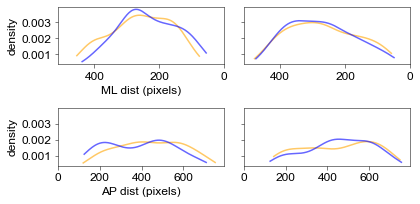

In [7]:
## Get ROI centers of mass as KDE
ML_bins = np.arange(0,512,20)
AP_bins = np.arange(0,796,20)
fig, ax = plt.subplots(2,2,figsize=[6,3], sharey=True)

## ML KDE
sns.kdeplot(roi_RR_COM[rr_planes==0,0], ax=ax[0,0],  color='orange', cut=0, alpha=0.6)
sns.kdeplot(roi_TR_COM[tr_planes==0,0], ax=ax[0,0], color='blue',cut=0,alpha=0.6)

sns.kdeplot(roi_RR_COM[rr_planes==1,0], ax=ax[0,1],  color='orange',cut=0,alpha=0.6)
sns.kdeplot(roi_TR_COM[tr_planes==1,0], ax=ax[0,1], color='blue',cut=0,alpha=0.6)


ax[0,0].set_xlabel('ML dist (pixels)')
ax[0,0].set_ylabel('density')
ax[0,0].set_xlim([0,512]), ax[0,1].set_xlim([0,512])
ax[0,0].invert_xaxis(), ax[0,1].invert_xaxis()

## AP KDE
sns.kdeplot(roi_RR_COM[rr_planes==0,1], ax=ax[1,0],  color='orange',cut=0,alpha=0.6)
sns.kdeplot(roi_TR_COM[tr_planes==0,1], ax=ax[1,0], color='blue',cut=0,alpha=0.6)

# for the second plane, subtract 796 pixels because suite2p concatenates the planes horizontally
sns.kdeplot(roi_RR_COM[rr_planes==1,1]-796, ax=ax[1,1],  color='orange',cut=0,alpha=0.6)
sns.kdeplot(roi_TR_COM[tr_planes==1,1]-796, ax=ax[1,1], color='blue',cut=0,alpha=0.6)


ax[1,0].set_xlabel('AP dist (pixels)')
ax[1,0].set_ylabel('density')

ax[1,0].set_xlim([0,796]), ax[1,1].set_xlim([0,796])

save_figures = False
if save_figures:
    fig.savefig(os.path.join(fig_dir, ("%s_day%d_ML-AP_ROI_KDE.svg" % (an, day))))

## Quantification

In [ ]:
# Get ML/AP COM and depth estimates from z-stack, as a dataframe, for all animals
save_figures = False
col = ['mouse', 'day', 'com_x', 'com_y', 'celltype', 'plane', 'depth']
df_rr = pd.DataFrame(columns=col)
df_tr = pd.DataFrame(columns=col)

for an_i, an in enumerate(include_ans):

    for d_i, day in enumerate(exp_days):

        sess = ut.load_sess_pickle(
            path_dict['preprocessed_root'], an, exp_day=day)

        _stats = sess.s2p_stats  # [sess.iscell[:,0]>0]

        # Note: sess.s2p_ops['Ly'] is the 512 pixel dimension, ML, which we label "x" to match the scanner motion
        #       sess.s2p_ops['Lx'] is the 796 pixel dimension, AP, which we label "y"
        roi_RR = np.zeros([sess.s2p_ops['Ly'], sess.s2p_ops['Lx']])*np.nan
        roi_TR = np.zeros([sess.s2p_ops['Ly'], sess.s2p_ops['Lx']])*np.nan
        roi_RR_COM = np.zeros(
            (len(multiDayData[day].reward_rel_cell_ids[an]), 2))

        tr_inds = np.where(
            multiDayData[day].cell_class[an]['masks']['track'])[0]
        tr_inds = tr_inds[~np.isin(
            tr_inds, multiDayData[day].reward_rel_cell_ids[an])]
        roi_TR_COM = np.zeros((len(tr_inds), 2))

        rr_planes = multiDayData[day].plane_per_cell[an][multiDayData[day].reward_rel_cell_ids[an]]
        tr_planes = multiDayData[day].plane_per_cell[an][tr_inds]

        if an not in ['GCAMP17', 'GCAMP18']:
            rr_depths = z_depth_per_cell[an][day][multiDayData[day].reward_rel_cell_ids[an]]
            tr_depths = z_depth_per_cell[an][day][tr_inds]
        else:
            # zstack depths for multiplane animals not currently implemented
            rr_depths = np.zeros(
                (len(multiDayData[day].reward_rel_cell_ids[an]),))*np.nan
            tr_depths = np.zeros((len(tr_inds),))*np.nan

            # Get from zstack depths
            rr_depths = z_depth_per_cell[an][day][multiDayData[day].reward_rel_cell_ids[an]]

            tr_inds = np.where(
                multiDayData[day].cell_class[an]['masks']['track'])[0]
            tr_inds = tr_inds[~np.isin(
                tr_inds, multiDayData[day].reward_rel_cell_ids[an])]

            tr_depths = z_depth_per_cell[mouse][day][tr_inds]

        # [rr_planes==plane]
        for i, roi in enumerate(multiDayData[day].reward_rel_cell_ids[an]):

            this_roi_mask = np.zeros([sess.s2p_ops['Ly'], sess.s2p_ops['Lx']])
            this_roi_mask[_stats[roi]['ypix'], _stats[roi]['xpix']] = 1
            roi_RR[_stats[roi]['ypix'], _stats[roi]['xpix']] = 1

            roi_RR_COM[i, :] = sp.ndimage.center_of_mass(this_roi_mask)

        for i, roi in enumerate(tr_inds):

            this_roi_mask = np.zeros([sess.s2p_ops['Ly'], sess.s2p_ops['Lx']])
            this_roi_mask[_stats[roi]['ypix'], _stats[roi]['xpix']] = 1
            roi_TR[_stats[roi]['ypix'], _stats[roi]['xpix']] = 1

            roi_TR_COM[i, :] = sp.ndimage.center_of_mass(this_roi_mask)

        df_rr_this_day = pd.DataFrame({'mouse': np.repeat(an, roi_RR_COM.shape[0]),
                                       'day': np.repeat(day, roi_RR_COM.shape[0]),
                                       'com_x': roi_RR_COM[:, 0],
                                       'com_y': roi_RR_COM[:, 1],
                                       'celltype': np.repeat('RR', roi_RR_COM.shape[0]),
                                       'plane': rr_planes,
                                       'depth': rr_depths,
                                       })
        df_tr_this_day = pd.DataFrame({'mouse': np.repeat(an, roi_TR_COM.shape[0]),
                                       'day': np.repeat(day, roi_TR_COM.shape[0]),
                                       'com_x': roi_TR_COM[:, 0],
                                       'com_y': roi_TR_COM[:, 1],
                                       'celltype': np.repeat('TR', roi_TR_COM.shape[0]),
                                       'plane': tr_planes,
                                       'depth': tr_depths,
                                       }
                                      )

        df_rr = df_rr.append(df_rr_this_day,
                             ignore_index=True)
        df_tr = df_tr.append(df_tr_this_day,
                             ignore_index=True)


# Put dataframes togther
df = df_rr.append(df_tr)
df['com_y'].loc[df['plane'] == 1] = df['com_y'].loc[df['plane'] == 1] - 796

In [9]:
sess.s2p_ops['Ly'], sess.s2p_ops['Lx']

(512, 796)

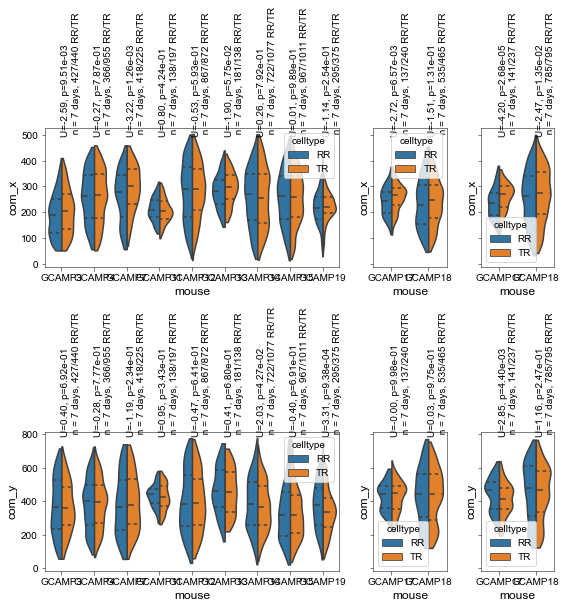

In [27]:
# violin plots of ML/AP distributions

fig, ax = plt.subplots(2, 3, figsize=[8, 8.5], gridspec_kw={
                       'width_ratios': [2, 0.5, 0.5]}, sharey='row')
sns.violinplot(data=df.loc[~np.isin(df['mouse'], ['GCAMP17', 'GCAMP18'])],
               x="mouse", y="com_x", hue="celltype", split=True, inner="quart", gap=.1, cut=0,
               ax=ax[0, 0], density_norm='count')

sns.violinplot(data=df.loc[~np.isin(df['mouse'], ['GCAMP17', 'GCAMP18'])],
               x="mouse", y="com_y", hue="celltype", split=True, inner="quart", gap=.1, cut=0,
               ax=ax[1, 0], density_norm='count')


for an_i, an in enumerate(use_anim_list):
    # print('ML mouse', an)
    ML_st = sp.stats.ranksums(df['com_x'][(df['mouse'] == an) & (df['celltype'] == 'RR')],
                              df['com_x'][(df['mouse'] == an) &
                                          (df['celltype'] == 'TR')],
                              )

    # print('AP mouse', an)
    AP_st = sp.stats.ranksums(df['com_y'][(df['mouse'] == an) & (df['celltype'] == 'RR')],
                              df['com_y'][(df['mouse'] == an) &
                                          (df['celltype'] == 'TR')],
                              )
    ax[0, 0].text(x=an_i, y=500, s=("U=%.2f, p=%.2e \n n = %d days, %d/%d RR/TR" % (
        ML_st.statistic,
        ML_st.pvalue,
        len(np.unique(df['day'][(df['mouse'] == an)
                                & (df['celltype'] == 'RR')])),
        len(df['com_x'][(df['mouse'] == an) & (df['celltype'] == 'RR')]),
        len(df['com_x'][(df['mouse'] == an) & (df['celltype'] == 'TR')])
    )),
        rotation=90)

    ax[1, 0].text(x=an_i, y=800, s=("U=%.2f, p=%.2e \n n = %d days, %d/%d RR/TR" % (
        AP_st.statistic,
        AP_st.pvalue,
        len(np.unique(df['day'][(df['mouse'] == an)
                                & (df['celltype'] == 'RR')])),
        len(df['com_y'][(df['mouse'] == an) & (df['celltype'] == 'RR')]),
        len(df['com_y'][(df['mouse'] == an) & (df['celltype'] == 'TR')])
    )),
        rotation=90)

sns.violinplot(data=df[(np.isin(df['mouse'], ['GCAMP17', 'GCAMP18'])) & (df['plane'] == 0)],
               x="mouse", y="com_x", hue="celltype", split=True, inner="quart", gap=.1, cut=0,
               ax=ax[0, 1], density_norm='count')

sns.violinplot(data=df[np.isin(df['mouse'], ['GCAMP17', 'GCAMP18']) & (df['plane'] == 0)],
               x="mouse", y="com_y", hue="celltype", split=True, inner="quart", gap=.1, cut=0,
               ax=ax[1, 1], density_norm='count')

sns.violinplot(data=df[(np.isin(df['mouse'], ['GCAMP17', 'GCAMP18'])) & (df['plane'] == 1)],
               x="mouse", y="com_x", hue="celltype", split=True, inner="quart", gap=.1, cut=0,
               ax=ax[0, 2], density_norm='count')

sns.violinplot(data=df[np.isin(df['mouse'], ['GCAMP17', 'GCAMP18']) & (df['plane'] == 1)],
               x="mouse", y="com_y", hue="celltype", split=True, inner="quart", gap=.1, cut=0,
               ax=ax[1, 2], density_norm='count')

for an_i, an in enumerate(['GCAMP17', 'GCAMP18']):
    ML_st_0 = sp.stats.ranksums(df['com_x'][(df['mouse'] == an) & (df['celltype'] == 'RR') & (df['plane'] == 0)],
                                df['com_x'][(df['mouse'] == an) & (
                                    df['celltype'] == 'TR') & (df['plane'] == 0)],
                                )

    AP_st_0 = sp.stats.ranksums(df['com_y'][(df['mouse'] == an) & (df['celltype'] == 'RR') & (df['plane'] == 0)],
                                df['com_y'][(df['mouse'] == an) & (
                                    df['celltype'] == 'TR') & (df['plane'] == 0)],
                                )

    ML_st_1 = sp.stats.ranksums(df['com_x'][(df['mouse'] == an) & (df['celltype'] == 'RR') & (df['plane'] == 1)],
                                df['com_x'][(df['mouse'] == an) & (
                                    df['celltype'] == 'TR') & (df['plane'] == 1)],
                                )

    AP_st_1 = sp.stats.ranksums(df['com_y'][(df['mouse'] == an) & (df['celltype'] == 'RR') & (df['plane'] == 1)],
                                df['com_y'][(df['mouse'] == an) & (
                                    df['celltype'] == 'TR') & (df['plane'] == 1)],
                                )

    ax[0, 1].text(x=an_i, y=500, s=("U=%.2f, p=%.2e \n n = %d days, %d/%d RR/TR" % (
        ML_st_0.statistic,
        ML_st_0.pvalue,
        len(np.unique(df['day'][(df['mouse'] == an) & (
            df['celltype'] == 'RR') & (df['plane'] == 0)])),
        len(df['com_x'][(df['mouse'] == an) & (
            df['celltype'] == 'RR') & (df['plane'] == 0)]),
        len(df['com_x'][(df['mouse'] == an) & (
            df['celltype'] == 'TR') & (df['plane'] == 0)])
    )),
        rotation=90)

    ax[1, 1].text(x=an_i, y=800, s=("U=%.2f, p=%.2e \n n = %d days, %d/%d RR/TR" % (
        AP_st_0.statistic,
        AP_st_0.pvalue,
        len(np.unique(df['day'][(df['mouse'] == an) & (
            df['celltype'] == 'RR') & (df['plane'] == 0)])),
        len(df['com_y'][(df['mouse'] == an) & (
            df['celltype'] == 'RR') & (df['plane'] == 0)]),
        len(df['com_y'][(df['mouse'] == an) & (
            df['celltype'] == 'TR') & (df['plane'] == 0)])
    )),
        rotation=90)

    ax[0, 2].text(x=an_i, y=500, s=("U=%.2f, p=%.2e \n n = %d days, %d/%d RR/TR" % (
        ML_st_1.statistic,
        ML_st_1.pvalue,
        len(np.unique(df['day'][(df['mouse'] == an) & (
            df['celltype'] == 'RR') & (df['plane'] == 1)])),
        len(df['com_x'][(df['mouse'] == an) & (
            df['celltype'] == 'RR') & (df['plane'] == 1)]),
        len(df['com_x'][(df['mouse'] == an) & (
            df['celltype'] == 'TR') & (df['plane'] == 1)])
    )),
        rotation=90)

    ax[1, 2].text(x=an_i, y=800, s=("U=%.2f, p=%.2e \n n = %d days, %d/%d RR/TR" % (
        AP_st_1.statistic,
        AP_st_1.pvalue,
        len(np.unique(df['day'][(df['mouse'] == an) & (
            df['celltype'] == 'RR') & (df['plane'] == 1)])),
        len(df['com_y'][(df['mouse'] == an) & (
            df['celltype'] == 'RR') & (df['plane'] == 1)]),
        len(df['com_y'][(df['mouse'] == an) & (
            df['celltype'] == 'TR') & (df['plane'] == 1)])
    )),
        rotation=90)
save_figures = False
if save_figures:
    fig.savefig(os.path.join(fig_dir, ("%s_days%s_ML-AP_ROI_KDE.svg" %
                                       (ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days)))))

print('NOTE: blue/orange colors are flipped from the paper')

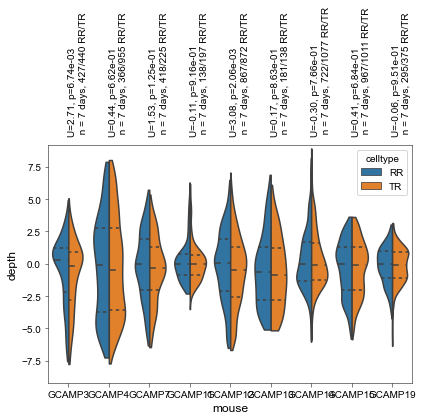

In [28]:
# Violin plot of depths for single plane animals

fig, ax = plt.subplots(figsize=[6,6])
sns.violinplot(data=df.loc[~np.isin(df['mouse'], ['GCAMP17','GCAMP18'])], 
               x="mouse", y="depth", hue="celltype", split=True, inner="quart", gap=.1, cut=0,
               ax=ax, density_norm='count')


for an_i, an in enumerate(use_anim_list):
    st = sp.stats.ranksums(df['depth'][(df['mouse']==an) & (df['celltype']=='RR')],
                            df['depth'][(df['mouse']==an) & (df['celltype']=='TR')], 
                           )

    ax.text(x=an_i, y=10, s=("U=%.2f, p=%.2e \n n = %d days, %d/%d RR/TR" % (
        st.statistic, 
        st.pvalue,
        len(np.unique(df['day'][(df['mouse']==an) & (df['celltype']=='RR')])),
        len(df['depth'][(df['mouse']==an) & (df['celltype']=='RR')]),
         len(df['depth'][(df['mouse']==an) & (df['celltype']=='TR')])
    )),
        rotation=90)

ax.set_ylim([-9.2,9.2])

save_figures = False
if save_figures:
    fig.savefig(os.path.join(fig_dir, ("%s_days%s_depth_ROI_KDE.svg" % (ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days)))))

In [31]:
df_src_xy = df_rr.append(df_tr) #df_rr[df_rr['mouse'].isin(['GCAMP17','GCAMP18'])]
ut.write_source_csv(df_src_xy, "Ext7b-c")
df_src_xy

writing /data/2P/source_data/FigExt7b-c.csv


,mouse,day,com_x,com_y,celltype,plane,depth
0,GCAMP3,3,125.651429,96.440000,RR,0.0,1.652035
1,GCAMP3,3,250.670588,304.529412,RR,0.0,0.526501
2,GCAMP3,3,225.865169,201.617978,RR,0.0,0.541222
3,GCAMP3,3,64.612245,524.809524,RR,0.0,0.333729
4,GCAMP3,3,157.452632,493.494737,RR,0.0,-5.826405
...,...,...,...,...,...,...,...
7022,GCAMP19,14,277.702970,497.891089,TR,0.0,-1.806633
7023,GCAMP19,14,76.565789,448.585526,TR,0.0,0.618134
7024,GCAMP19,14,279.329545,465.465909,TR,0.0,-1.223801
7025,GCAMP19,14,298.576087,218.043478,TR,0.0,-0.625305


In [34]:
df_src_z = df_src_xy[~df_src_xy['mouse'].isin(['GCAMP17','GCAMP18'])]
# ut.write_source_csv(df_src_z, "Ext7h")


writing /data/2P/source_data/FigExt7h.csv
